# 코호트 재구매율 분석

`RFM_4rd_processed`에서 분리한 탐색적 코호트 분석 노트북.

**독립 실행:** `retail_preprocessed.parquet`만 로드하면 되며, RFM/패널/군집화 파이프라인과 무관하다.

**취소 처리:** 데이터는 net-sales 방식이라 취소(C 인보이스·음수 수량) 행이 살아 있다.
코호트는 "구매 시점"만 보므로, 코호트월 산출과 재구매 판정 모두 `is_purchase`(정상 구매)만 사용한다.
Monetary≤0 제거 등 RFM 전용 처리는 코호트에 불필요하므로 적용하지 않는다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 윈도우 기준 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (00_전처리 산출물 — is_purchase / is_cancel 포함) ──
df = pd.read_parquet('../data/retail_preprocessed.parquet')

# 회원만 (비회원은 고객 귀속 불가 → 코호트 분석 대상 아님)
df = df.dropna(subset=['Customer ID']).copy()

print("로드 완료:", df.shape)
print("is_purchase 컬럼 존재:", 'is_purchase' in df.columns)
print("취소(is_cancel) 행:", int(df['is_cancel'].sum()) if 'is_cancel' in df.columns else 'N/A')

로드 완료: (794165, 13)
is_purchase 컬럼 존재: True
취소(is_cancel) 행: 17586


In [4]:
# ============================================================
# 코호트 컬럼 생성 (★ 정상구매 is_purchase 기준)
#   - 취소월이 코호트로 잡히는 것 방지
#   - 취소 거래에도 경과월은 붙지만, 재구매 판정 단계에서 is_purchase로 다시 거른다
# ============================================================

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 코호트월 = 정상구매의 첫 달
pur = df[df['is_purchase']]
df['CohortMonth'] = df['Customer ID'].map(
    pur.groupby('Customer ID')['InvoiceMonth'].min()
)

# 정상구매가 하나도 없는 고객(취소전용)은 CohortMonth = NaN → 경과월도 NaN
df['PeriodNumber'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(
    lambda x: x.n if pd.notna(x) else np.nan
)

print("취소전용 고객(코호트 결측) 행:", int(df['CohortMonth'].isna().sum()))
print(df[['Customer ID', 'CohortMonth', 'PeriodNumber']].head())

취소전용 고객(코호트 결측) 행: 87
  Customer ID CohortMonth  PeriodNumber
0       13085     2009-12           0.0
1       13085     2009-12           0.0
2       13085     2009-12           0.0
3       13085     2009-12           0.0
4       13085     2009-12           0.0


In [5]:
# ============================================================
# 오염 검증 — 재구매로 잡힌 취소가 0이어야 정상
# ============================================================
rep = df[df['is_purchase'] & (df['PeriodNumber'] >= 1)]
if 'is_cancel' in df.columns:
    print("재구매(is_purchase & period>=1)로 잡힌 취소:", int(rep['is_cancel'].sum()), "(0이어야 정상)")

재구매(is_purchase & period>=1)로 잡힌 취소: 0 (0이어야 정상)


In [6]:
# ============================================================
# 1. 고객별 첫 재구매 시점 (★ 정상구매만)
#    FirstRepurchase = 첫 구매 이후 처음 재구매까지 걸린 개월 수, 없으면 NaN
# ============================================================
customer_repurchase = df[df['is_purchase']].groupby('Customer ID').agg(
    CohortMonth     = ('CohortMonth', 'first'),
    FirstRepurchase = ('PeriodNumber', lambda x: x[x >= 1].min())
).reset_index()

customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)
print("고객 수:", len(customer_repurchase))
print("재구매 있는 고객:", customer_repurchase['FirstRepurchase'].notna().sum())

고객 수: 5852
재구매 있는 고객: 4094


In [9]:
# ============================================================
# 2. 코호트별 N개월 이내 누적 재구매율
#    N개월 내 재구매 = 첫 재구매가 p개월 이내 (FirstRepurchase <= p)
# ============================================================
periods = [1, 3, 6, 9, 12]
cohort_list = sorted(customer_repurchase['CohortStr'].unique())

cumulative_data = []
for cohort in cohort_list:
    cohort_customers = customer_repurchase[customer_repurchase['CohortStr'] == cohort]
    row = {'Cohort': cohort, '신규유입': len(cohort_customers)}
    for p in periods:
        rate = (cohort_customers['FirstRepurchase'] <= p).mean() * 100
        row[f'+{p}개월'] = rate
    cumulative_data.append(row)

cumulative_df = pd.DataFrame(cumulative_data).set_index('Cohort')

# 12개월 관찰 가능 구간까지만
cumulative_df = cumulative_df[cumulative_df.index <= '2010-11']

value_cols = [f'+{p}개월' for p in periods]
print("=== 누적 재구매율 표 ===")
print(cumulative_df[value_cols].round(1).to_string())

=== 누적 재구매율 표 ===
         +1개월  +3개월  +6개월  +9개월  +12개월
Cohort                                
2009-12  35.0  63.0  77.5  82.8   88.4
2010-01  21.5  55.4  74.5  83.7   86.4
2010-02  23.5  52.3  66.1  76.8   79.5
2010-03  19.0  44.2  61.2  72.8   77.3
2010-04  19.0  38.1  61.2  69.0   72.8
2010-05  15.7  35.3  60.8  62.7   69.0
2010-06  17.6  38.2  59.9  64.0   67.0
2010-07  15.7  44.3  58.4  63.2   68.1
2010-08  19.6  50.3  52.1  59.5   62.6
2010-09  23.0  42.3  51.5  56.5   64.4
2010-10  25.9  37.1  45.6  51.7   58.7
2010-11  17.5  25.2  34.7  40.5   53.1


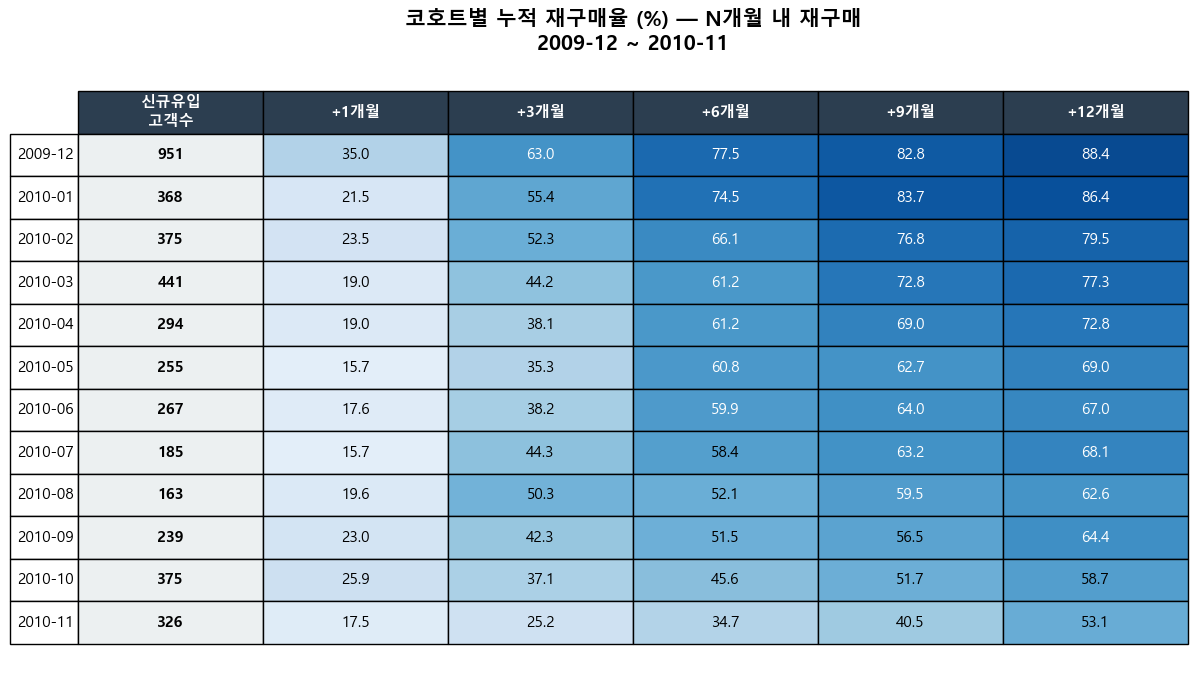

In [10]:
# ============================================================
# 3. 표 시각화 (재구매율 높을수록 진한 파랑)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['신규유입\n고객수'] + [f'+{p}개월' for p in periods]
row_labels = cumulative_df.index.tolist()

cell_text = []
for cohort in cumulative_df.index:
    row = [f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        row.append(f"{cumulative_df.loc[cohort, f'+{p}개월']:.1f}")
    cell_text.append(row)

table = ax.table(cellText=cell_text, rowLabels=row_labels,
                 colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.2)

all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()
blues = plt.cm.Blues

for i, cohort in enumerate(cumulative_df.index):
    for j, p in enumerate(periods):
        val = cumulative_df.loc[cohort, f'+{p}개월']
        cell = table[i+1, j+1]
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0
        cell.set_facecolor(blues(0.1 + norm * 0.8))
        if norm > 0.6:
            cell.set_text_props(color='white')

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(len(row_labels)):
    table[i+1, 0].set_facecolor('#ecf0f1')
    table[i+1, 0].set_text_props(fontweight='bold')

plt.title('코호트별 누적 재구매율 (%) — N개월 내 재구매\n2009-12 ~ 2010-11',
          fontsize=15, fontweight='bold', pad=1)
plt.tight_layout()
plt.savefig('cohort_cumulative_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()